## Read the data

In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils.utils import read_diderm_data, pca_run_and_plot, tsne_plot

TAX_LEVEL = "phylum" # <----------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_diderm"  # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
use_gpu = torch.cuda.is_available()

# --- output dir ---
if not os.path.exists(f"{OUTPUT_DIRECTORY}/plots"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/plots")

In [3]:
from tqdm import tqdm
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in tqdm(range(NUM_SPLITS_TO_READ), desc="Processing splits..."):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_train, y_label_train, X_column_names, taxa_group_names_train = read_diderm_data(data_filename_train, y_filename_train, taxa_names_filename_train, DEVICE)

    # Read validation data
    data_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_val, y_label_val, X_column_names, taxa_group_names_val = read_diderm_data(data_filename_val, y_filename_val, taxa_names_filename_val, DEVICE)  
    
    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    X_val_test, y_label_test, X_column_names, taxa_group_names_test = read_diderm_data(data_filename_test, y_filename_test, taxa_names_filename_test, DEVICE)

    if sum(y_label_test) == 0 or sum(y_label_train) == 0:
        continue

    if TAX_LEVEL == "random":
        taxa_group_names_train = None
        taxa_group_names_test = None

    if X_val_train is not None and y_label_train is not None and X_val_test is not None and y_label_test is not None and X_val_val is not None and y_label_val is not None:
        curr_split_dict = defaultdict(str)
        curr_split_dict["X_train"] = X_val_train
        curr_split_dict["y_train"] = y_label_train
        curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
        curr_split_dict["X_test"] = X_val_test
        curr_split_dict["y_test"] = y_label_test
        curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
        curr_split_dict["X_val"] = X_val_val
        curr_split_dict["y_val"] = y_label_val
        curr_split_dict["taxa_group_names_val"] = taxa_group_names_val
        curr_split_dict["feature_names"] = X_column_names

        all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")            

Processing splits...: 100%|█████████████████████████████████████████████████████████████████| 30/30 [00:58<00:00,  1.97s/it]

Number of added splits = 29


### Prediction accuracy test for the train data with duplicated samples (no noise)

In [4]:
import joblib
from collections import defaultdict
from tqdm import tqdm
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (
    matthews_corrcoef,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

tree_method = "gpu_hist" if use_gpu else "hist"

def make_xgb():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1
    )  

In [5]:
x_arr = [0, 5, 10, 20, 50, 100, 200, 400]
mcc_for_dupl = {}    
for x in x_arr:
    noise_type = 'exp' # <---------can be any because we are exploring the case of the data with noise-free duplicates (i.e. lambda_fp = lambda_fn = 0)
    filename = f"trained_models_fp_0.0_fn_0.0_noise_type_{noise_type}_x_{x}.pkl"
    filepath = f"{OUTPUT_DIRECTORY}/trained_models/{filename}"
    mcc_for_dupl_local = []
    metrics_accum = {key: [] for key in ["mcc", "accuracy", "balanced_accuracy", "precision", "recall", "f1"]}
    
    if os.path.exists(filepath):
        loaded_models_dict = joblib.load(filepath)
        
        for split_id in loaded_models_dict.keys():
            trained_model = loaded_models_dict[split_id]
            X_val_test = all_splits_dict[split_id]["X_test"]
            y_label_test = all_splits_dict[split_id]["y_test"]
            y_pred = trained_model.predict(X_val_test)
            mcc_for_dupl_local.append(matthews_corrcoef(y_label_test.cpu(), y_pred))
    else:
        for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
            X_val_train = all_splits_dict[split_id]["X_train"]
            y_label_train = all_splits_dict[split_id]["y_train"]
            X_val_test = all_splits_dict[split_id]["X_test"]
            y_label_test = all_splits_dict[split_id]["y_test"]
    
            N = x + 1
            X_val_train_dup = X_val_train.repeat((N, 1))   
            y_label_train_dup = y_label_train.repeat(N) 
    
            idx = torch.randperm(X_val_train_dup.size(0))  
            X_val_train_dup = X_val_train_dup[idx]
            y_label_train_dup = y_label_train_dup[idx]
    
            pipe = make_pipeline(make_xgb())
            pipe.fit(X_val_train_dup, y_label_train_dup)
            y_pred = pipe.predict(X_val_test)
    
            mcc_for_dupl_local.append(matthews_corrcoef(y_label_test.cpu(), y_pred))        
    mcc_for_dupl[x] = (np.mean(mcc_for_dupl_local), np.std(mcc_for_dupl_local))  

Training splits: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:30<00:00,  1.04s/it]
/home/a/an-koldaeva/local/python3.11/lib/python3.11/pickle.py:1718: UserWarning: [16:03:27] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


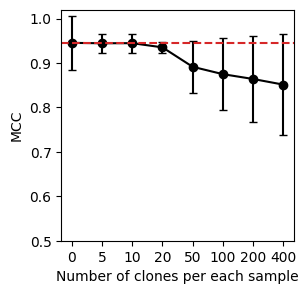

In [6]:
plt.figure(figsize=(3,3))

n_clones = mcc_for_dupl.keys()
mean_arr = [mcc_for_dupl[key][0] for key in mcc_for_dupl.keys()]
std_arr = [mcc_for_dupl[key][1] for key in mcc_for_dupl.keys()]
plt.axhline(y=mcc_for_dupl[0][0], color='tab:red', linestyle='--', linewidth=1.5)
plt.errorbar(range(len(n_clones)), mean_arr, yerr=std_arr, marker='o', capsize=3, linestyle='-', c='black', zorder=-1)

plt.ylim([0.5, 1.02])    
plt.xticks(range(len(n_clones)), n_clones)  
plt.xlabel("Number of clones per each sample")
plt.ylabel("MCC")
plt.show()

## Noize tolerance of the original model

Here we train the original models for each train/test split and explore their performance on the noisy test data. The noise on the test dataset is implemented as the fraction false positives and false negatives.

In [5]:
cog_remov_add_accuracies = defaultdict(dict)

device = DEVICE
cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]

noise_std = 0.3

trained_models = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    pipe = make_pipeline(
        make_pipeline(XGBClassifier(n_jobs=THREADS if device == "cpu" else None, tree_method="gpu_hist" if device == "cpu" else "hist"))
    )
    pipe.fit(X_val_train.cpu(), y_label_train.cpu())
    trained_models[split_id] = pipe

Training splits: 100%|██████████████████████████████████████████████████████████████████████| 29/29 [00:05<00:00,  5.24it/s]


In [6]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data

cog_remov_add_accuracies_orig_models = eval_trained_models_on_noisy_data(all_splits_dict, trained_models, hard_fn_flag = True, test_or_val = "test")

In [7]:
def plot_one_accur_measure(ax, accuracy_measure, cog_remov_add_accuracies, alpha=1):
    cog_remov_add_accuracies_one_measure = defaultdict()
    for key in cog_remov_add_accuracies.keys():
        cog_remov_add_accuracies_one_measure[key] = cog_remov_add_accuracies[key][accuracy_measure]
    
    rem_rates = sorted(set(k[0] for k in cog_remov_add_accuracies_one_measure.keys()))
    add_rates = sorted(set(k[1] for k in cog_remov_add_accuracies_one_measure.keys()))
  #  add_rates = [0.0, 0.05, 0.1]  <------ you can select FP rates for the plot
    
    cmap = plt.cm.tab10
    colors = [cmap(i / (len(rem_rates)-1)) for i in range(len(rem_rates))]

    for i, ar in enumerate(add_rates):
        means = []
        stds = []
        rem_rate_values = []
        for rr in rem_rates:
            key = (rr, ar)
            if key in cog_remov_add_accuracies_one_measure:
                mean, std = cog_remov_add_accuracies_one_measure[key]
                means.append(mean)
                stds.append(std)
                rem_rate_values.append(rr)
        ax.errorbar(rem_rate_values, means, yerr=stds, label = fr"$r_{{FP}}={ar}$", marker='o', capsize=3, linestyle='-', color=colors[i], alpha=alpha)
    
    ax.set_xlabel(r"$r_{FN}$", fontsize=FONTSIZE)
    ax.tick_params(axis='x', labelsize=FONTSIZE)
    ax.tick_params(axis='y', labelsize=FONTSIZE)

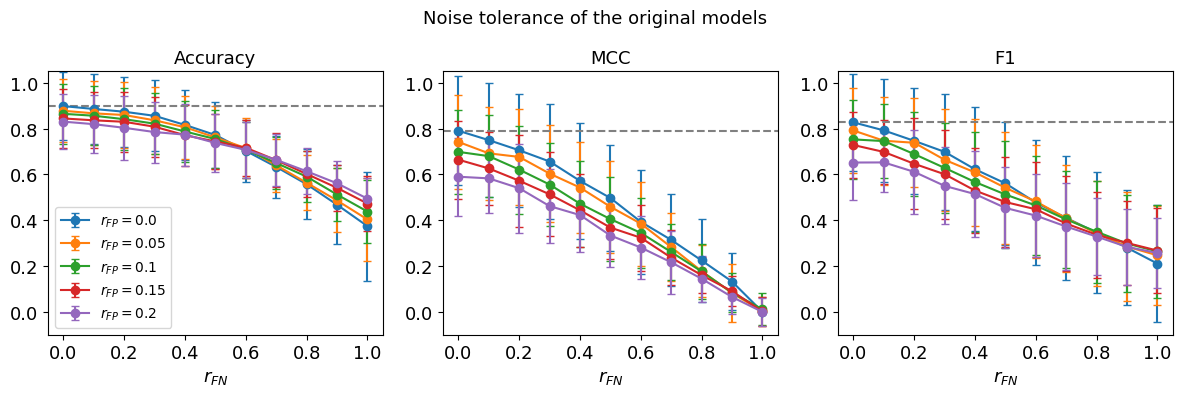

In [8]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

# Accuracy
fig, axes = plt.subplots(1,3, figsize=(12,4))
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Accuracy", fontsize=FONTSIZE)
axes[0].legend()

# MCC
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)

# F1
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models", fontsize=FONTSIZE)    
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf


## The models trained on noisy data

In [9]:
import os
from xgboost import XGBClassifier, XGBRegressor
from sklearn.pipeline import make_pipeline

device = DEVICE
THREADS = os.cpu_count()

# GPU / CPU setup 
use_gpu = torch.cuda.is_available()

TRAINED_MOD_DIR = "trained_models_train_val_test"

def make_xgb():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1
    )

In [10]:
def plot_model_groups(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm", value = "Mean"):
    data = []
    for (fp, fn), (mean, std) in noise_increase_accuracy_one_metric.items():
        data.append([fp, fn, mean, std])
    df = pd.DataFrame(data, columns=["FP", "FN", "Mean", "Std"])
    
    pivot = df.pivot(index="FP", columns="FN", values=value)
    pivot = pivot.astype(float) 
    mask = pivot.isna() 
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax, mask=mask, ax=ax, cbar=False)


Processing noise rates...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:08<00:00,  4.05it/s]


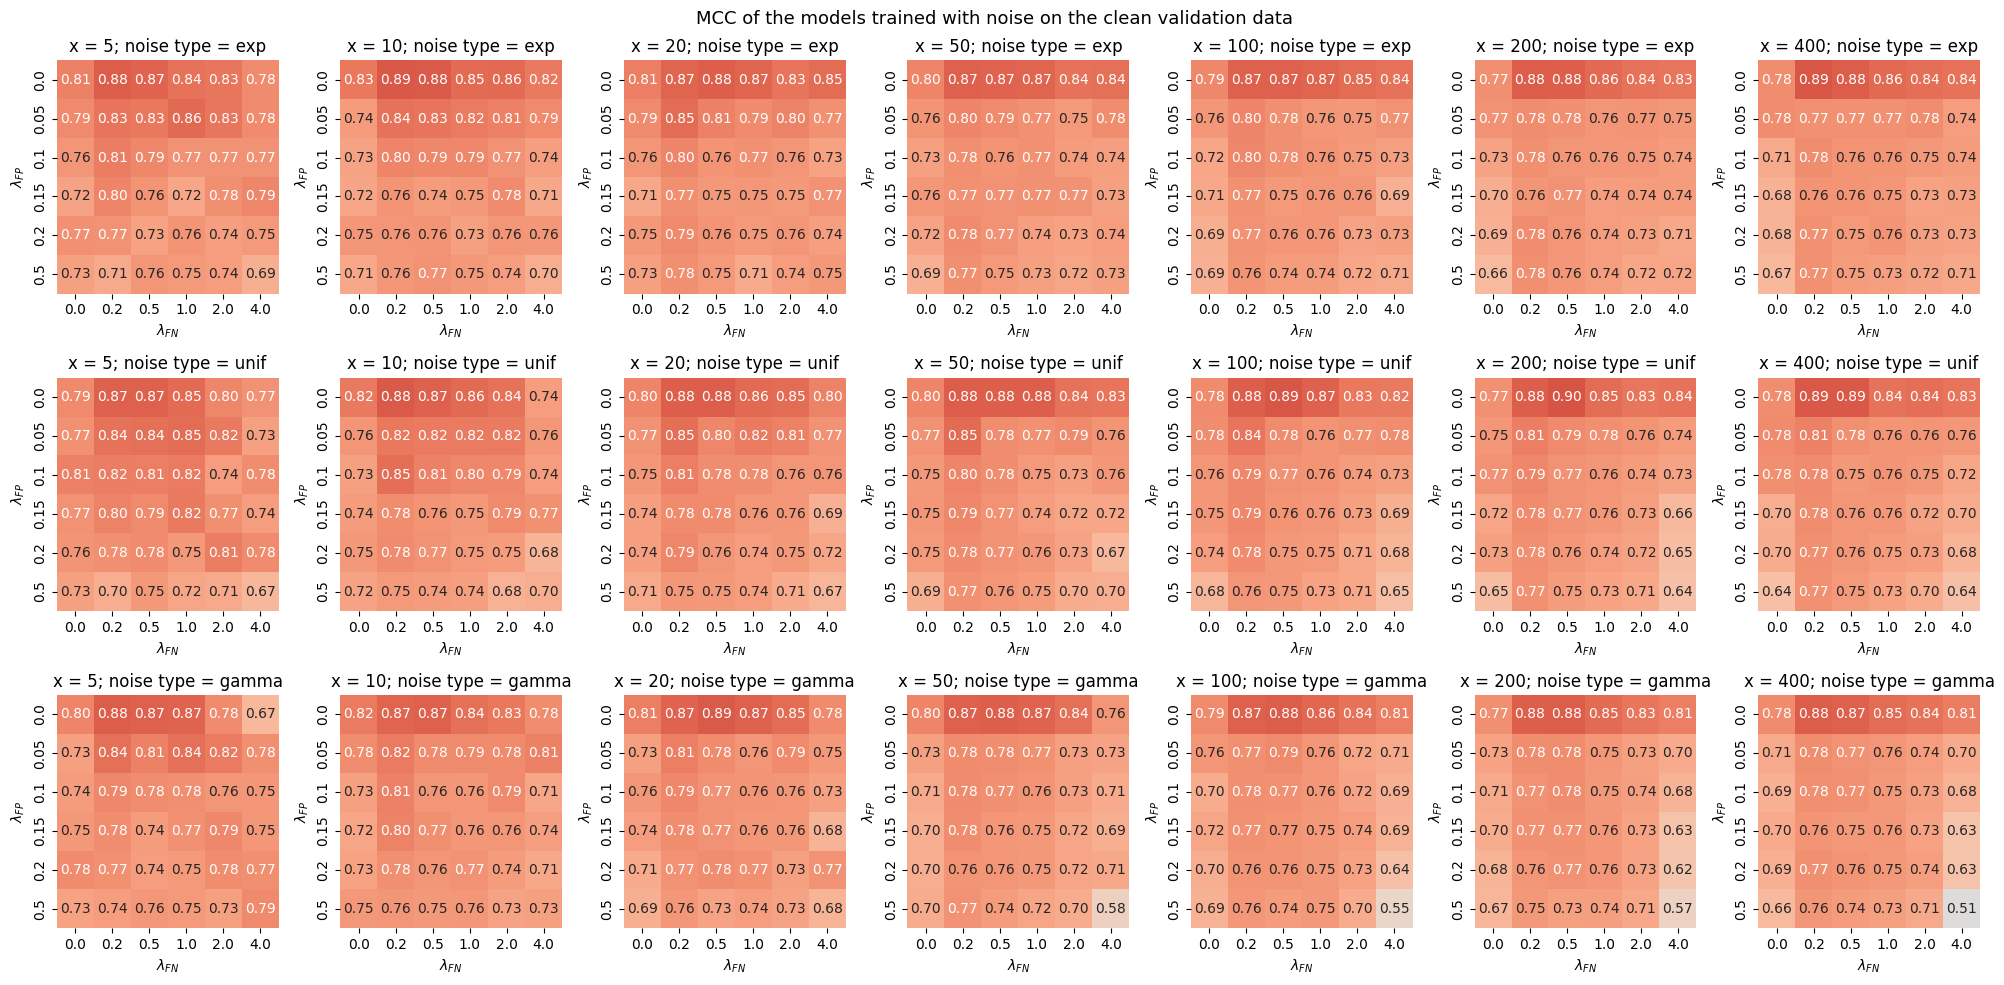

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from utils.utils_ancestral_predict import  read_and_evaluate_models_for_x_and_sigma

FONTSIZE=13

metric = 'mcc'
x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)
       # areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(f"MCC of the models trained with noise on the clean validation data", fontsize=FONTSIZE)   
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf        

Processing noise rates...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:15<00:00,  2.38it/s]


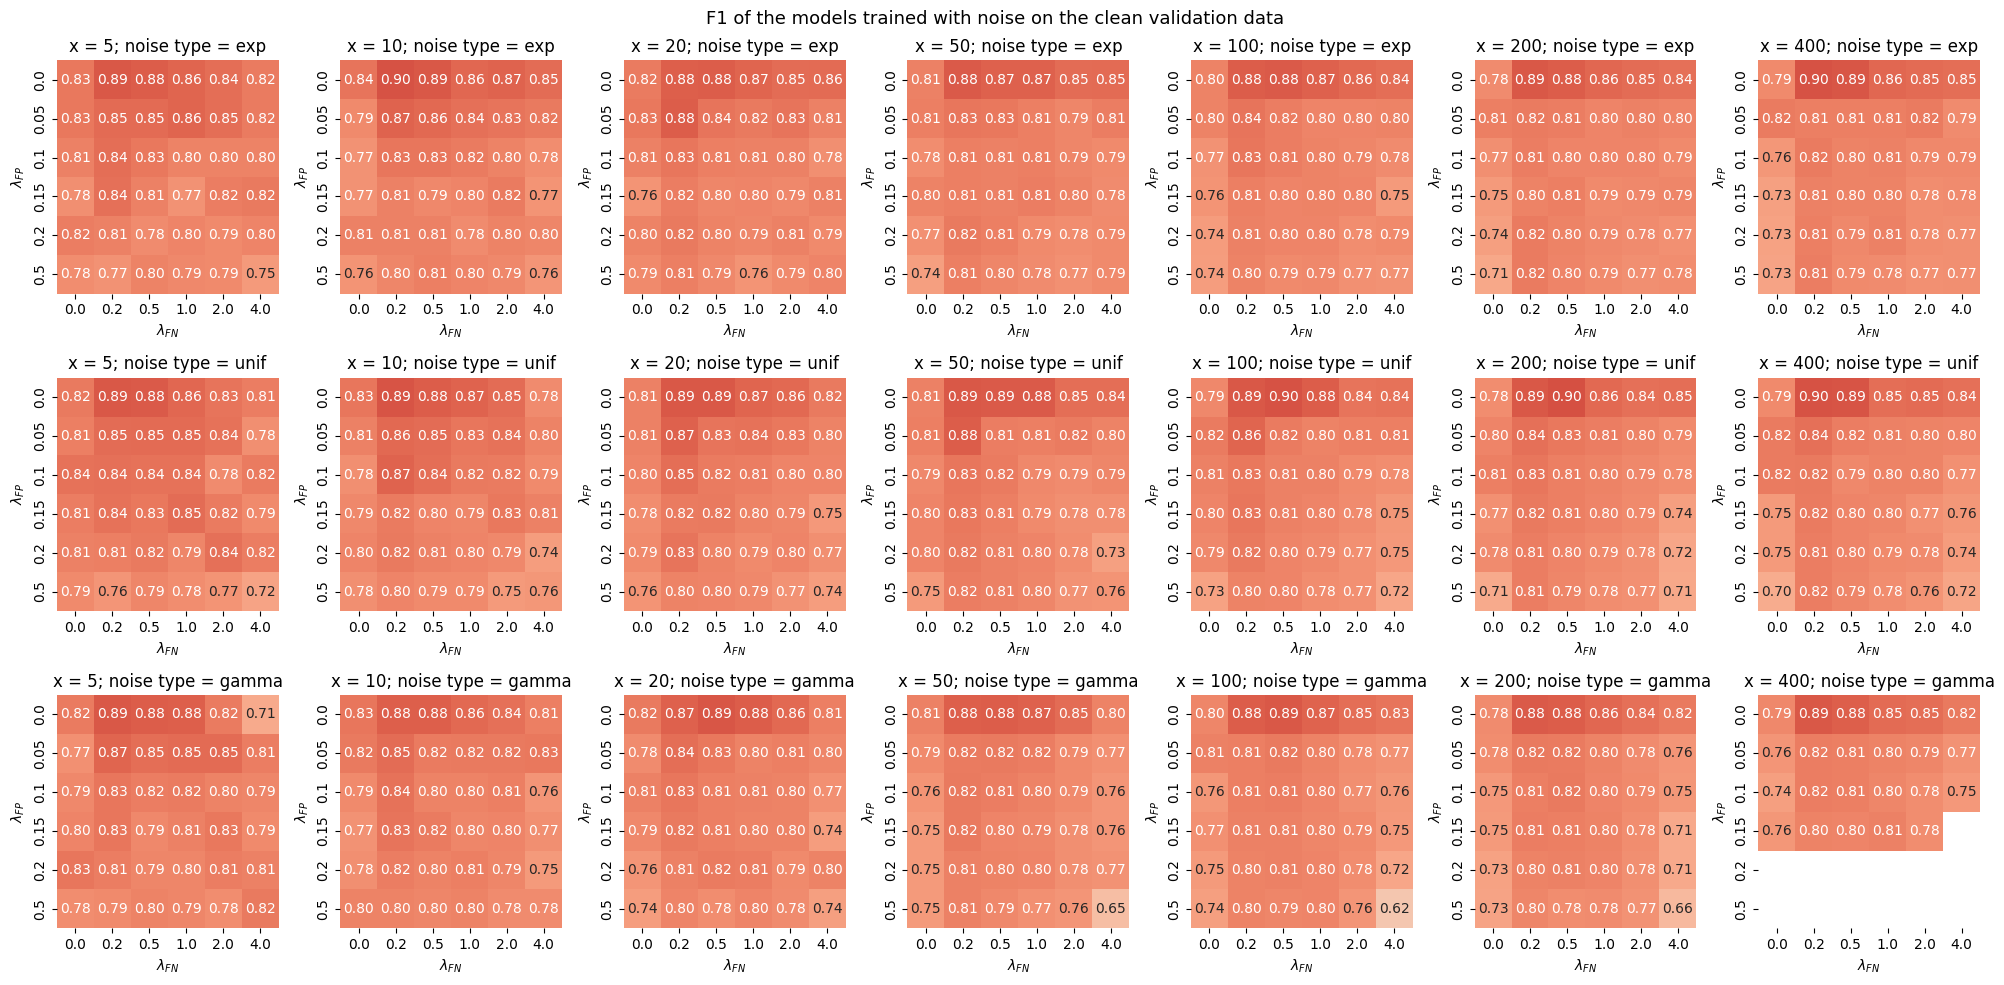

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metric = 'f1'
x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = True, add_rate = None, rem_rate = None, noise_std = None, hard_fn_flag = None)
       # areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(f"F1 of the models trained with noise on the clean validation data", fontsize=FONTSIZE)  
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf        

## Noisy models on noisy data

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

test_fp = 0.1
test_fn = 0.5

Processing noise rates...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:15<00:00,  2.30it/s]


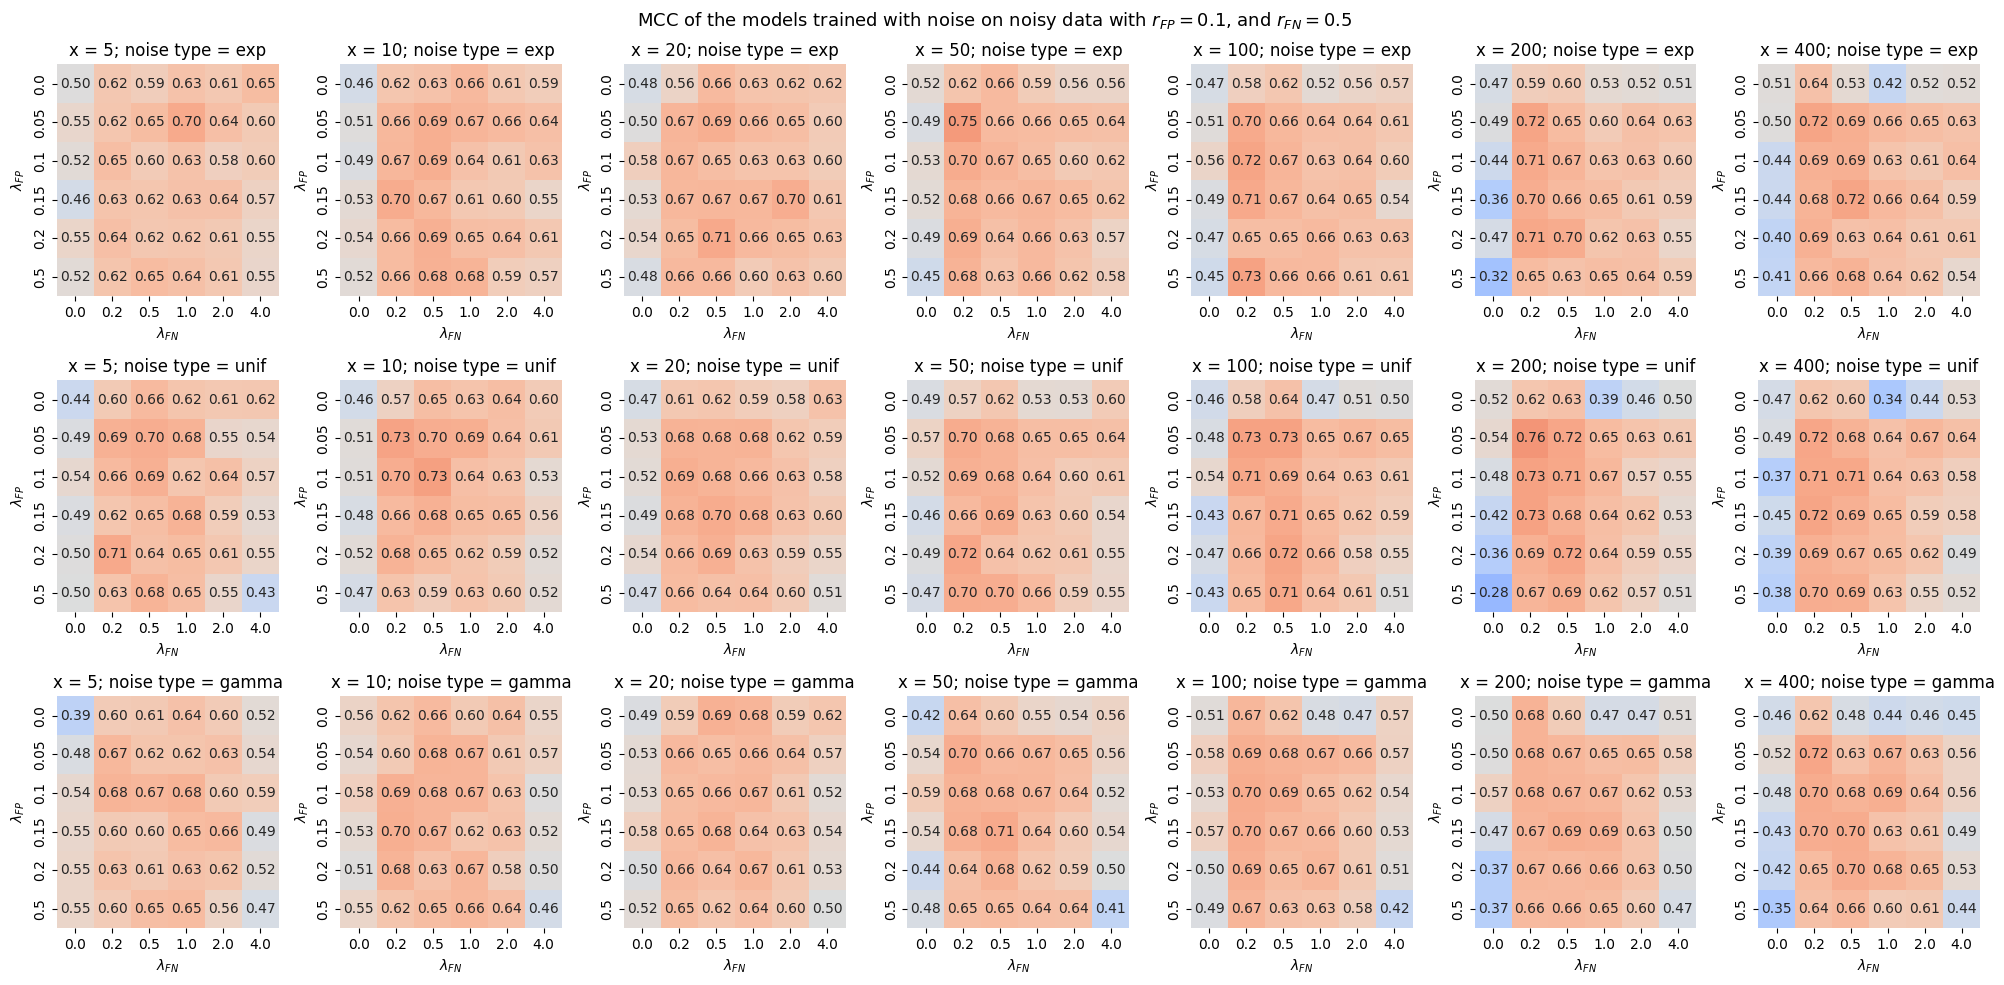

In [11]:
metric = 'mcc'
areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
      #  areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC of the models trained with noise on noisy data with $r_{{FP}} = {test_fp}$, and $r_{{FN}} = {test_fn}$", fontsize=FONTSIZE)
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_noisy_test_FP_{test_fp}_FN_{test_fn}_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf    

Processing noise rates...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:16<00:00,  2.16it/s]


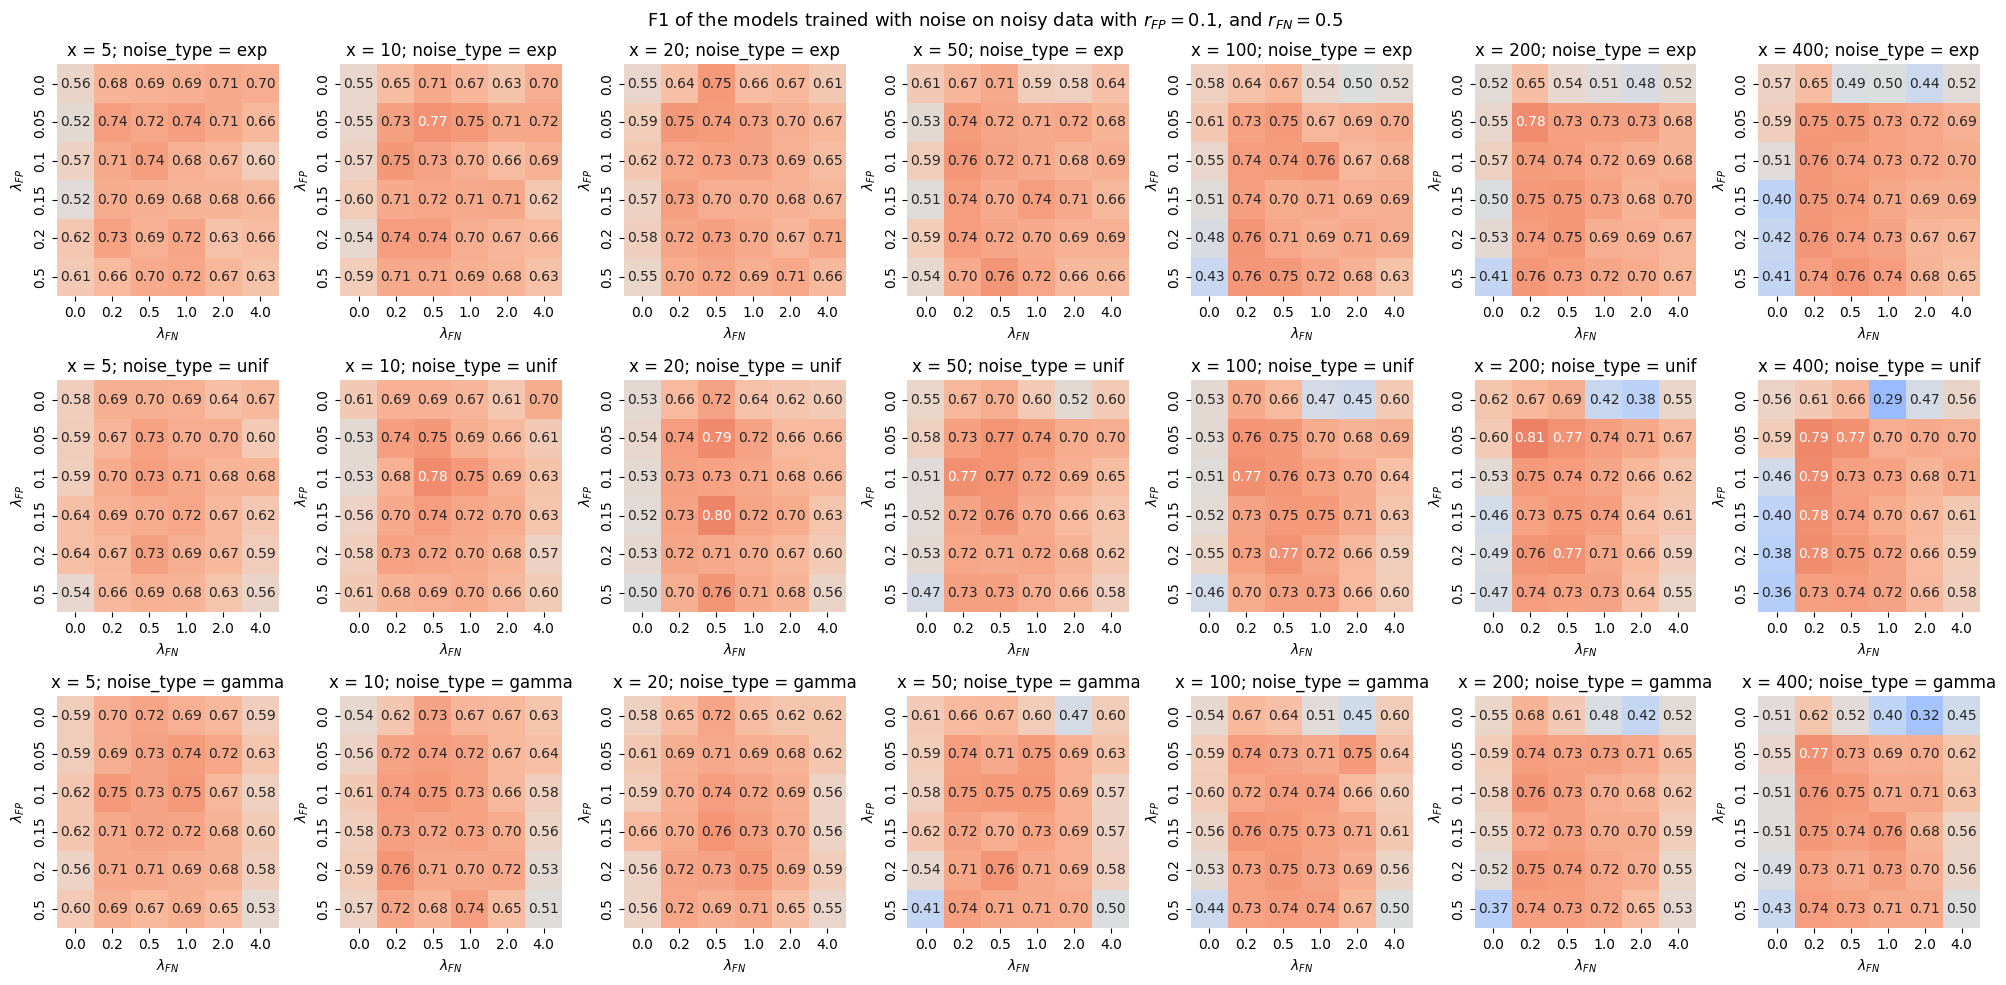

In [12]:
metric = 'f1'

areas_noise_type_x = {}

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(noise_type_range):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        noise_increase_accuracy_one_metric = read_and_evaluate_models_for_x_and_sigma(TRAINED_MOD_DIR, x, noise_type, metric, all_splits_dict, OUTPUT_DIRECTORY, clean_test_flag = False, add_rate = test_fp, rem_rate = test_fn, noise_std = 0.3, hard_fn_flag = None)
        #areas_noise_type_x[(x, noise_type)] = areas_mn_std

        plot_model_groups(noise_increase_accuracy_one_metric, ax)
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")
plt.suptitle(rf"F1 of the models trained with noise on noisy data with $r_{{FP}} = {test_fp}$, and $r_{{FN}} = {test_fn}$", fontsize=FONTSIZE)
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_clean_test_{metric}.svg", format="svg") #<----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_models_on_noisy_test_FP_{test_fp}_FN_{test_fn}_{metric}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf    

### Analyze the performance of the models on the wide noise range [0, max_fp], [0, max_fn]

Processing noise types:   0%|                                                                         | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...


Processing noise types:  33%|█████████████████████▎                                          | 1/3 [15:49<31:38, 949.10s/it]

Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...


Processing noise types:  67%|██████████████████████████████████████████                     | 2/3 [35:56<18:20, 1100.97s/it]

Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...
Saving the dict...


Processing noise types: 100%|███████████████████████████████████████████████████████████████| 3/3 [55:46<00:00, 1115.52s/it]


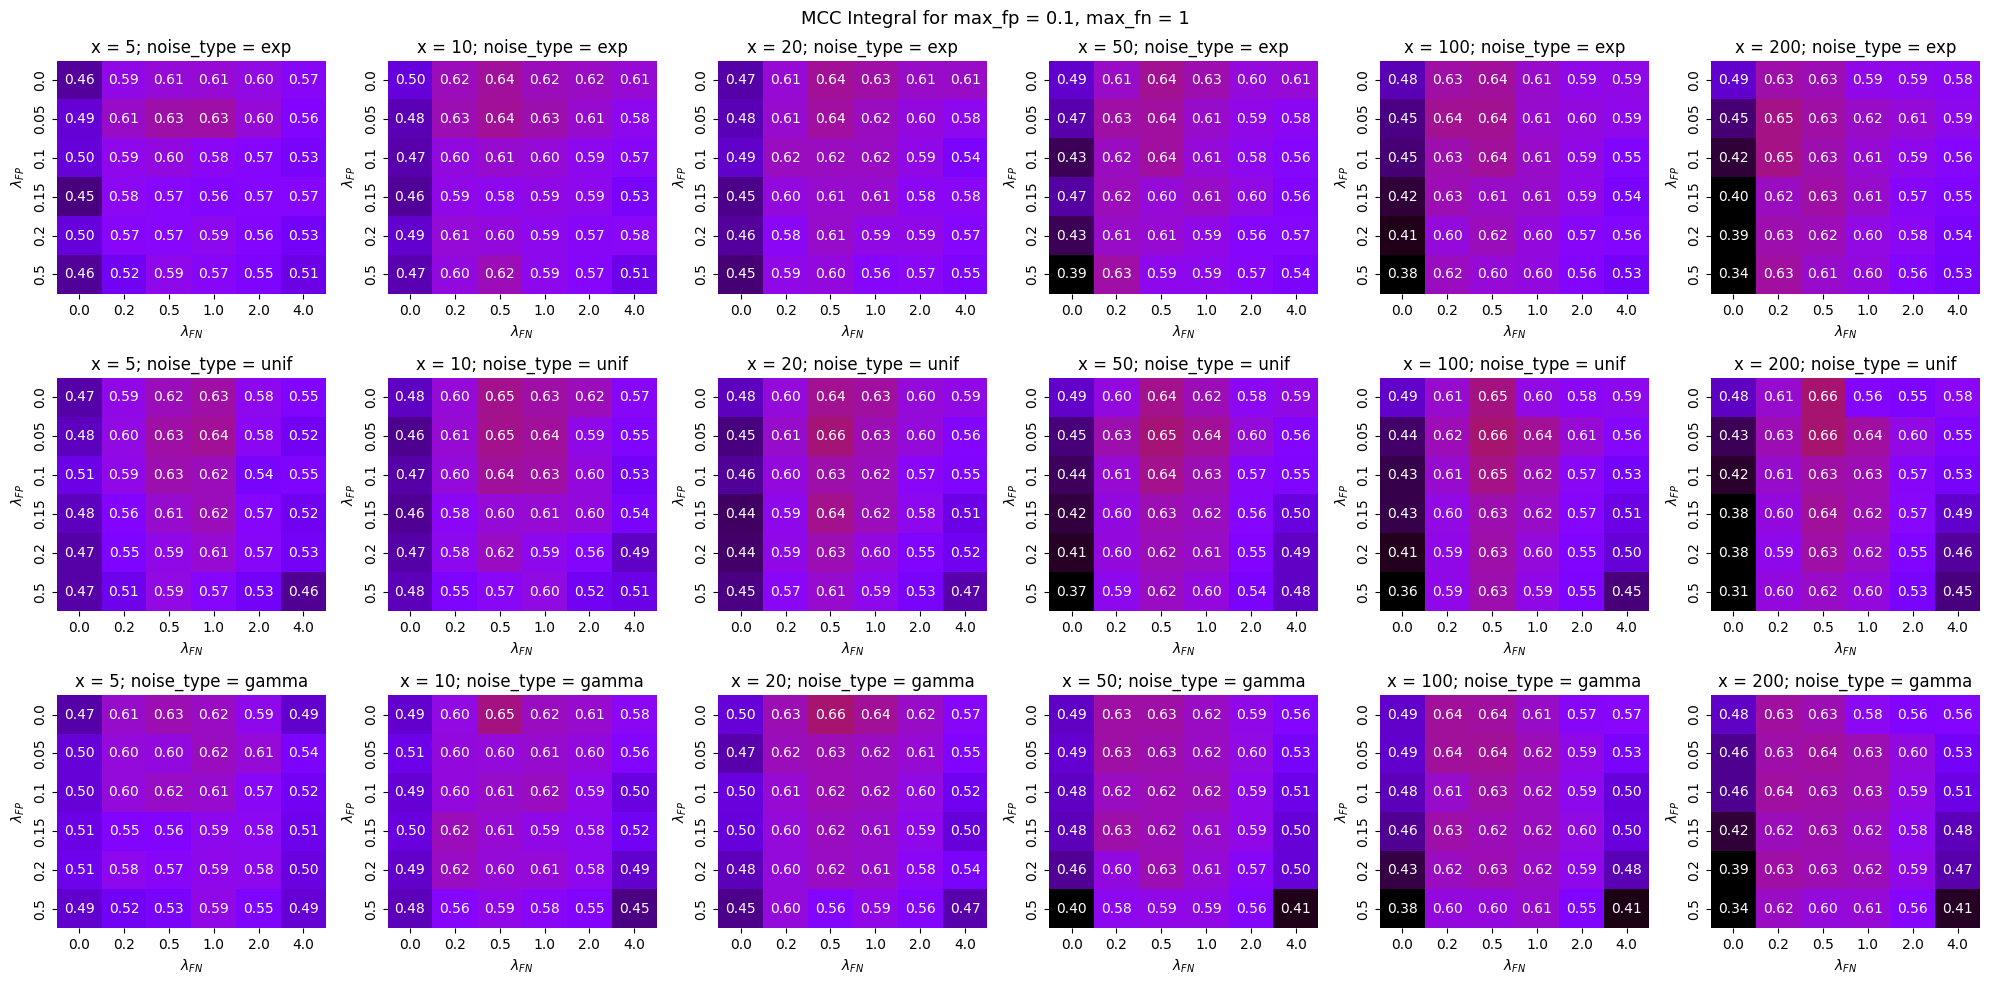

In [16]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data, fp_curve_areas_one_model

fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]#[0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]#[0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]
x_range = [5, 10, 20, 50, 100, 200]#, 400]
noise_type_range = ["exp", "unif", "gamma"]

max_fp = 0.1
max_fn = 1

FONTSIZE = 13

fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"curve_integrals_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = [np.mean(fp_curve_areas), np.std(fp_curve_areas)]

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups(one_accur_dict, ax, vmin=0.4, vmax=1, cmap="gnuplot", value = "Mean")
   #     plot_model_groups(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

Processing noise types:   0%|                                                                         | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|█████████████████████▋                                           | 1/3 [00:02<00:05,  2.87s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|███████████████████████████████████████████▎                     | 2/3 [00:06<00:03,  3.12s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████| 3/3 [00:08<00:00,  2.84s/it]


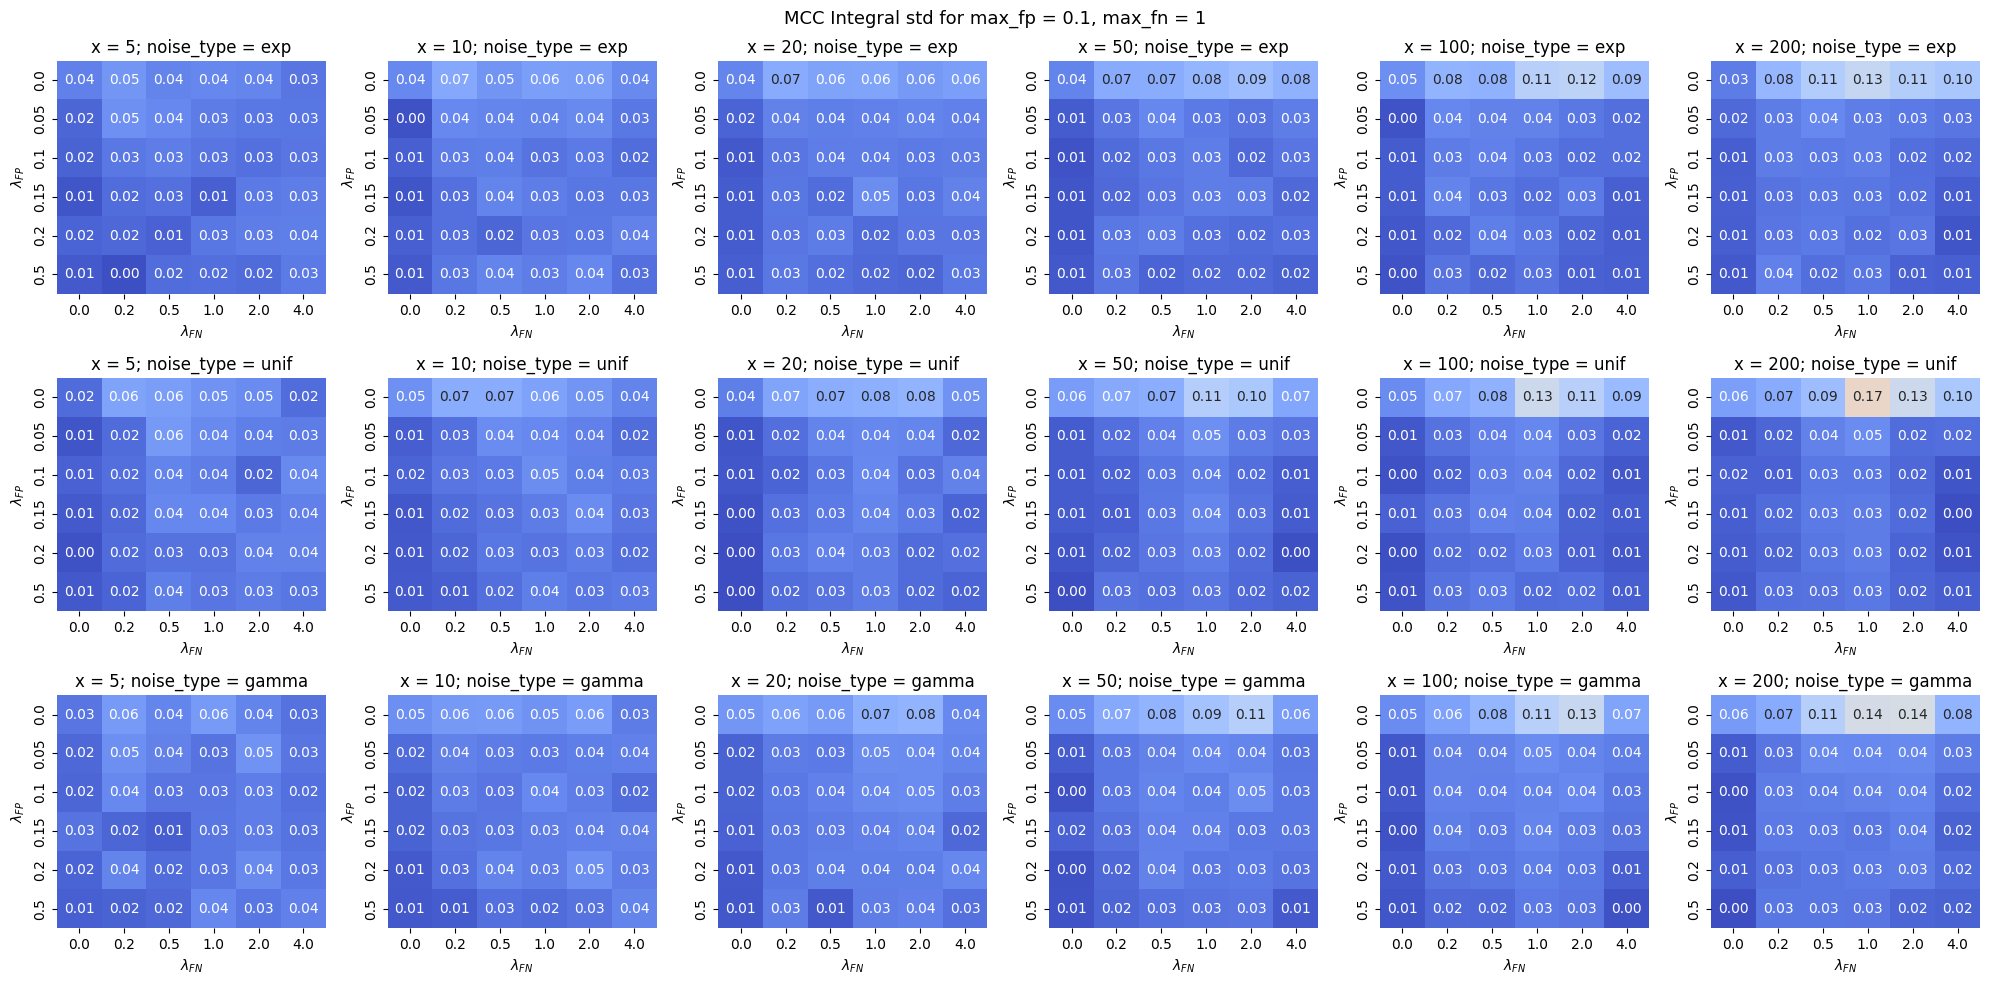

In [17]:
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"curve_integrals_max_fp_{max_fp}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_curve_areas = fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = [np.mean(fp_curve_areas), np.std(fp_curve_areas)]

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")


        plot_model_groups(one_accur_dict, ax, vmin=0.0, vmax=0.3, cmap="coolwarm", value = "Std")
       # plot_model_groups(noise_increase_accuracy_one_metric, ax, vmin=0.0, vmax=1, cmap="coolwarm", value = "Std")
       # plot_model_groups(one_accur_dict, ax, vmin=0.3, vmax=0.8, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral std for max_fp = {max_fp}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

In [19]:
max_fp = 0.1
cog_adding_rates = [fp for fp in [0.0, 0.05, 0.1, 0.15, 0.2] if fp <= max_fp]
cog_removal_rates = [fn for fn in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] if fn <= max_fn]
cog_removal_rates

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

In [20]:
np.trapezoid([1]*len(cog_removal_rates), cog_removal_rates)

np.float64(1.0)

### Visualize the results for the chosen model

In [18]:
import joblib

# Choose a model
x_noisy_samples = 100
fp_rate_mean = 0.1# 0.05
fn_rate_mean = 0.5#0.5
noise_type = "exp"

filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")

In [19]:
from utils.utils_ancestral_predict import  eval_trained_models_on_noisy_data
cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = 0.15, max_fn = 1, test_or_val = "test")

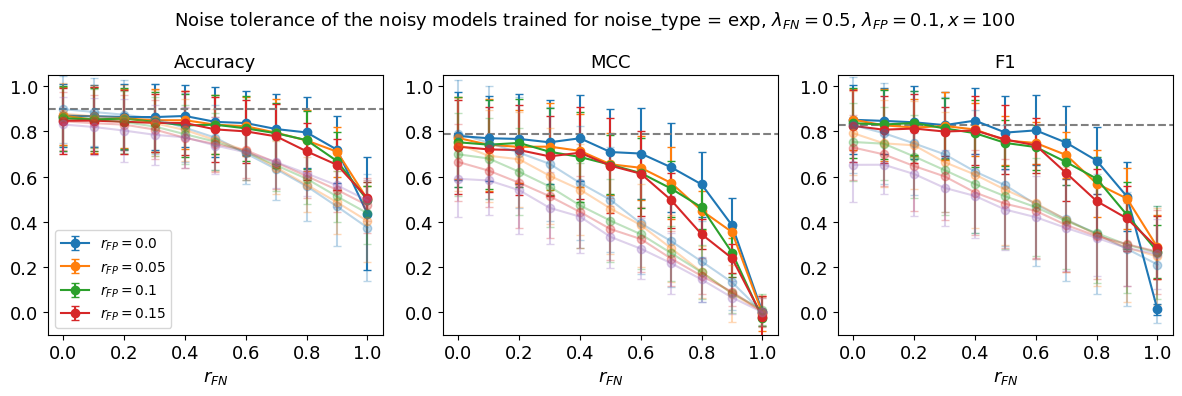

In [20]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,3, figsize=(12,4))

plt.subplot(1, 3, 1)
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies)
axes[0].legend()
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Accuracy", fontsize=FONTSIZE)


plt.subplot(1, 3, 2)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)

plt.subplot(1, 3, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the noisy models trained for noise_type = {noise_type}, $\lambda_{{FN}} = {fn_rate_mean}$, $\lambda_{{FP}} = {fp_rate_mean}, x = {x_noisy_samples}$", fontsize=FONTSIZE)
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

## Ancestral Data

In [12]:
leaves_acc_names = pd.read_csv("../ancestral_data/GenomesInfo.csv", sep=",")
columns_to_keep = ['accession', 'ShortCode']
leaves_acc_names = leaves_acc_names[columns_to_keep]
leaves_acc_names

,accession,ShortCode
0,GB_GCA_003599535.1,AABM5X1
1,GB_GCA_005223185.1,AABM5X2
2,GB_GCA_002127415.1,AABM5X3
3,GB_GCA_003598085.1,Abys1
4,GB_GCA_003223555.1,Acid1
...,...,...
1002,GB_GCA_001775395.1,Zixi1
1003,GB_GCA_002791595.1,Zixi2
1004,GB_GCA_003105265.1,Zixi3
1005,GB_GCA_002838945.1,Zixi4


In [13]:
diderm_annot = pd.read_csv("../data_diderm/gold_standard1.tsv", sep="\t")
num_samples = diderm_annot.shape[0]
diderm_annot

,accession,high_throughput_dermy
0,GB_GCA_000018565.1,Monoderm
1,GB_GCA_000091165.1,Diderm
2,GB_GCA_000252485.1,Diderm
3,GB_GCA_000276965.1,Diderm
4,GB_GCA_000353875.1,Diderm
...,...,...
923,RS_GCF_900187885.1,Monoderm
924,RS_GCF_900215725.1,Monoderm
925,RS_GCF_900604345.1,Monoderm
926,RS_GCF_900626135.1,Monoderm


In [14]:
import polars as pl

BAC_TSV = '../data_preparation/gtdb_files/bac120_metadata_r202.tsv'
ARC_TSV = '../data_preparation/gtdb_files/ar122_metadata_r202.tsv'

tax_level = "phylum"
tax_levels = {"domain": 0, "phylum": 1, "class": 2, "order": 3, "family": 4}

gtdb_df = pl.concat([pl.read_csv(BAC_TSV, separator="\t"),
    pl.read_csv(ARC_TSV, separator="\t")])
gtdb_df = gtdb_df[['accession', "gtdb_taxonomy"]]
for key in tax_levels.keys():
    tax_level = tax_levels[key]
    gtdb_df = gtdb_df.with_columns(pl.col("gtdb_taxonomy").str.split(';').list.get(tax_levels[key]).alias(key))
gtdb_df = gtdb_df.drop("gtdb_taxonomy")
#gtdb_df = gtdb_df[['accession', tax_level]]
gtdb_df = gtdb_df.to_pandas()
gtdb_df

,accession,domain,phylum,class,order,family
0,GB_GCA_000013845.2,d__Bacteria,p__Firmicutes_A,c__Clostridia,o__Clostridiales,f__Clostridiaceae
1,GB_GCA_000016465.1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Enterobacterales,f__Pasteurellaceae
2,GB_GCA_000024525.1,d__Bacteria,p__Bacteroidota,c__Bacteroidia,o__Cytophagales,f__Spirosomaceae
3,GB_GCA_000152525.1,d__Bacteria,p__Proteobacteria,c__Gammaproteobacteria,o__Pseudomonadales,f__Pseudomonadaceae
4,GB_GCA_000172955.1,d__Bacteria,p__Campylobacterota,c__Campylobacteria,o__Campylobacterales,f__Helicobacteraceae
...,...,...,...,...,...,...
258401,RS_GCF_900109065.1,d__Archaea,p__Halobacteriota,c__Halobacteria,o__Halobacteriales,f__Haloferacaceae
258402,RS_GCF_900114585.1,d__Archaea,p__Methanobacteriota,c__Methanobacteria,o__Methanobacteriales,f__Methanobacteriaceae
258403,RS_GCF_900773915.1,d__Archaea,p__Halobacteriota,c__Methanosarcinia,o__Methanosarcinales,f__Methanosarcinaceae
258404,RS_GCF_902384055.1,d__Archaea,p__Methanobacteriota,c__Methanobacteria,o__Methanobacteriales,f__Methanobacteriaceae


In [15]:
leave_nodes_with_taxonomy = pd.merge(leaves_acc_names, gtdb_df, on="accession", how="inner")
leave_nodes_with_taxonomy

,accession,ShortCode,domain,phylum,class,order,family
0,GB_GCA_003599535.1,AABM5X1,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
1,GB_GCA_005223185.1,AABM5X2,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
2,GB_GCA_002127415.1,AABM5X3,d__Bacteria,p__AABM5-125-24,c__AABM5-125-24,o__AABM5-125-24,f__AABM5-125-24
3,GB_GCA_003598085.1,Abys1,d__Bacteria,p__Abyssubacteria,c__SURF-5,o__SURF-5,f__SURF-5
4,GB_GCA_003223555.1,Acid1,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Fen-336,f__Fen-336
...,...,...,...,...,...,...,...
992,GB_GCA_001775395.1,Zixi1,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UBA10806,f__UBA10806
993,GB_GCA_002791595.1,Zixi2,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UM-FILTER-46-8,f__UM-FILTER-46-8
994,GB_GCA_003105265.1,Zixi3,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__FEB-12
995,GB_GCA_002838945.1,Zixi4,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__PGXB01


In [16]:
df = pd.read_csv('../ancestral_data/MasterTableEvents.tsv', sep='\t', dtype={'column_name': str})
columns_to_keep = ['COG', 'BranchName', 'copies', 'BranchType']
df = df[columns_to_keep]
#df['presence'] = (df['presence'] >= 0.5).astype(int)
df

,COG,BranchName,copies,BranchType
0,COG5083,AABM5X1,0.0,S_terminal_branch
1,COG5083,AABM5X2,0.0,S_terminal_branch
2,COG5083,AABM5X3,0.0,S_terminal_branch
3,COG5083,Abys1,0.0,S_terminal_branch
4,COG5083,Acid1,0.0,S_terminal_branch
...,...,...,...,...
9706681,COG0115,2008,0.0,S_internal_branch
9706682,COG0115,2009,0.0,S_internal_branch
9706683,COG0115,2010,0.0,S_internal_branch
9706684,COG0115,2011,0.0,S_internal_branch


In [17]:
df_summed = df.groupby(['COG', 'BranchName'])['copies'].sum().reset_index()

pivot_df = df_summed.pivot(index='BranchName', columns='COG', values='copies').fillna(0)
pivot_df.index.name = None
pivot_df.rename(columns={'COG': 'nodes'}, inplace=True)
pivot_df

COG,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0009,COG0010,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
1007,0.77,0.22,0.18,0.11,0.31,2.15,1.03,0.77,1.35,0.61,...,0.01,0.0,0.03,0.0,0.0,0.00,0.0,0.03,0.06,0.02
1008,0.21,0.03,0.01,0.00,0.03,0.15,0.01,0.43,0.37,0.56,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.02,0.00
1009,0.42,0.28,0.43,0.11,0.80,1.51,0.01,0.25,0.64,0.31,...,0.18,0.0,0.10,0.0,0.0,0.00,0.0,0.00,0.08,0.01
1010,0.11,0.05,0.03,0.09,0.73,0.15,0.02,0.21,0.11,0.05,...,0.00,0.0,0.01,0.0,0.0,0.00,0.0,0.24,0.23,0.00
1011,1.19,0.58,2.12,0.27,1.49,1.03,0.06,0.44,1.58,1.13,...,0.00,0.0,0.31,0.0,0.0,0.01,0.0,0.04,0.04,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zixi1,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
Zixi2,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,1.00,1.00
Zixi3,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,1.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
Zixi4,1.00,0.00,0.00,0.00,0.00,3.00,1.00,1.00,1.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,1.00,0.00


In [18]:
node_names = pivot_df.index.tolist()
cogs_from_mastertable = list(pivot_df.columns)
len(cogs_from_mastertable)

2847

In [19]:
cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))
len(cogs_intersect)

2512

In [20]:
diderm_cogs = pd.read_csv("../data_diderm/all_gene_annotations.tsv", sep="\t")
merged_tab  = pd.merge(diderm_cogs, diderm_annot, on="accession", how="inner") 
merged_tab

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0007,COG0008,COG0010,COG0012,...,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663,high_throughput_dermy
0,GB_GCA_000018565.1,1,1,1,3,3,0,1,1,1,...,0,0,0,1,1,0,0,0,0,Monoderm
1,GB_GCA_000091165.1,2,1,0,2,1,1,1,0,1,...,0,1,0,0,0,0,0,0,1,Diderm
2,GB_GCA_000252485.1,1,1,2,3,1,1,0,0,1,...,0,0,0,1,0,0,0,0,0,Diderm
3,GB_GCA_000276965.1,1,1,0,3,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,Diderm
4,GB_GCA_000353875.1,1,1,0,1,0,1,2,0,1,...,0,0,0,0,0,0,0,0,0,Diderm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,RS_GCF_900215725.1,0,0,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,Monoderm
924,RS_GCF_900604345.1,0,1,0,1,1,0,1,0,1,...,0,0,0,2,0,0,0,0,0,Monoderm
925,RS_GCF_900626135.1,1,0,0,0,0,1,1,0,1,...,0,0,0,1,0,0,0,1,0,Monoderm
926,RS_GCF_900637055.1,2,1,1,1,0,1,1,1,1,...,0,0,0,3,0,0,0,1,1,Monoderm


In [21]:
y_label_train = torch.tensor(merged_tab["high_throughput_dermy"].map({"Monoderm": 1, "Diderm": 0}).to_numpy(), dtype=torch.long)

In [22]:
numeric_df = merged_tab.iloc[:, 1:-1]
numeric_values = torch.tensor(numeric_df.values, dtype=torch.float32)
numeric_values = (numeric_values> 0).int()  
numeric_values.shape

torch.Size([928, 2665])

In [23]:
X_column_names = merged_tab.columns.tolist()[1:-1]
name_to_idx = {name: i for i, name in enumerate(X_column_names)}

cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))
len(cogs_intersect)

2512

In [24]:
tree_nodes_data = pivot_df[cogs_intersect]
tree_nodes_data

COG,COG0001,COG0002,COG0003,COG0004,COG0005,COG0007,COG0008,COG0010,COG0012,COG0015,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
1007,0.77,0.22,0.18,0.11,0.31,1.03,0.77,0.61,1.19,0.73,...,0.01,0.0,0.03,0.0,0.0,0.00,0.0,0.03,0.06,0.02
1008,0.21,0.03,0.01,0.00,0.03,0.01,0.43,0.56,0.17,0.06,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.02,0.00
1009,0.42,0.28,0.43,0.11,0.80,0.01,0.25,0.31,0.53,1.31,...,0.18,0.0,0.10,0.0,0.0,0.00,0.0,0.00,0.08,0.01
1010,0.11,0.05,0.03,0.09,0.73,0.02,0.21,0.05,1.03,1.15,...,0.00,0.0,0.01,0.0,0.0,0.00,0.0,0.24,0.23,0.00
1011,1.19,0.58,2.12,0.27,1.49,0.06,0.44,1.13,1.62,1.65,...,0.00,0.0,0.31,0.0,0.0,0.01,0.0,0.04,0.04,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zixi1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
Zixi2,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,1.00,1.00
Zixi3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.00
Zixi4,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.0,0.00,0.0,0.00,1.00,0.00


In [25]:
# Keep only those in cogs_intersect AND present in X_column_names
keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

# Filter tensor and column names
X_val_train_filtered = numeric_values[:, keep_indices]
X_column_names_filtered = [X_column_names[i] for i in keep_indices]
X_val_train_filtered.shape

torch.Size([928, 2512])

# Check the model performance on the truncated feature set

In [26]:
cog_remov_add_accuracies = defaultdict(dict)

device = DEVICE
cog_removal_rates = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
cog_adding_rates = [0.0, 0.05, 0.1, 0.15, 0.2]

noise_std = 0.3

# -----------------------
# Train once per split_id
# -----------------------
trained_models_ancestral_feat = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    X_column_names =  all_splits_dict[split_id]["feature_names"]
    name_to_idx = {name: i for i, name in enumerate(X_column_names)}
    
    cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
    cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))

    keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

    X_val_train_filtered = X_val_train[:, keep_indices]

                                                            
    pipe = make_pipeline(
        make_pipeline(XGBClassifier(n_jobs=THREADS if device == "cpu" else None, tree_method="gpu_hist" if device == "cpu" else "hist"))
    )
    pipe.fit(X_val_train_filtered.cpu(), y_label_train.cpu())
    trained_models_ancestral_feat[split_id] = pipe

Training splits: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:09<00:00,  2.97it/s]


In [27]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data

cog_remov_add_accuracies_ancestr_feat_set = eval_trained_models_on_noisy_data(all_splits_dict, trained_models_ancestral_feat, hard_fn_flag = True, truncated_feature_set = keep_indices)

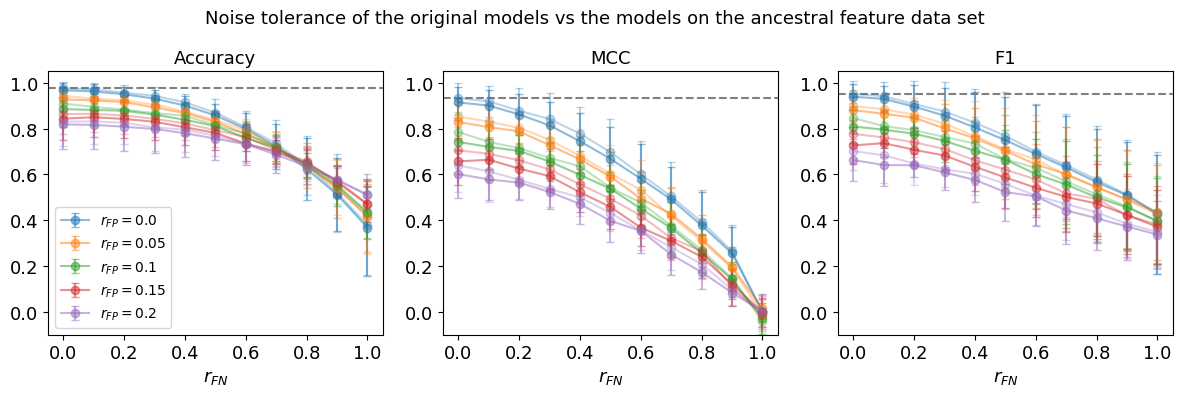

In [28]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,3, figsize=(12,4))

plt.subplot(1, 3, 1)
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_ancestr_feat_set, alpha=0.5)
axes[0].legend()
plot_one_accur_measure(axes[0], "accuracy", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['accuracy'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("Accuracy", fontsize=FONTSIZE)


plt.subplot(1, 3, 2)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_ancestr_feat_set, alpha=0.5)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)

plt.subplot(1, 3, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_ancestr_feat_set, alpha=0.5)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the original models vs the models on the ancestral feature data set", fontsize=FONTSIZE)
plt.tight_layout()

#plt.savefig(f"{OUTPUT_DIRECTORY}/plots/accur_fp_fn.svg", format="svg") <----------------------------save as svg
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_ancestr_feat_set.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

In [40]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = DEVICE

In [41]:
from utils.utils_ancestral_predict import augment_data_with_noise

In [47]:
# Augment X train with the noise 
x = 100
fp_rate_mean = 0.1
fn_rate_mean = 0.5
noise_type = "exp"#"exp"

pipe_with_noise = make_pipeline(make_xgb())

X_augmented, y_augmented = augment_data_with_noise(X_val_train_filtered, y_label_train, x, fp_rate_mean, fn_rate_mean, noise_type=noise_type, filename=None)

#X_augmented, y_augmented = augment_data_at_rate_and_length(X_val_train_filtered, y_label_train, x, fp_rate_mean, sigma_fp, fn_rate_mean, sigma_fn, hard_fn_flag = hard_fn_flag, noise_std=0.3)
#X_augmented, y_augmented = augment_data_at_rate_and_length_uniform(X_val_train_filtered, y_label_train, x, fp_rate_mean, fn_rate_mean,  hard_fn_flag = hard_fn_flag, noise_std=0.3)

X_augmented.shape

torch.Size([93728, 2512])

In [48]:
pipe = make_pipeline(make_xgb())
pipe.fit(X_augmented.cpu(), y_augmented.cpu());

In [49]:
## Applying to the unseen data
numeric_df = tree_nodes_data.select_dtypes(include=["number"])
ancestral_nodes_tensor = torch.tensor(numeric_df.to_numpy())

y_pred_ancestr_nodes = pipe.predict(ancestral_nodes_tensor.cpu())
y_pred_ancestr_nodes

array([0, 0, 0, ..., 0, 0, 0], shape=(2013,))

,accession,didermy,ShortCode
0,GB_GCA_000018565.1,Monoderm,Chlo27
1,GB_GCA_000091165.1,Diderm,Meth4
2,GB_GCA_000252485.1,Diderm,Cyan21
3,GB_GCA_000276965.1,Diderm,Camp2
4,GB_GCA_000353875.1,Diderm,Calda2
...,...,...,...
923,RS_GCF_900187885.1,Monoderm,Chlo33
924,RS_GCF_900215725.1,Monoderm,FirmA89
925,RS_GCF_900604345.1,Monoderm,FirmA73
926,RS_GCF_900626135.1,Monoderm,FirmA47


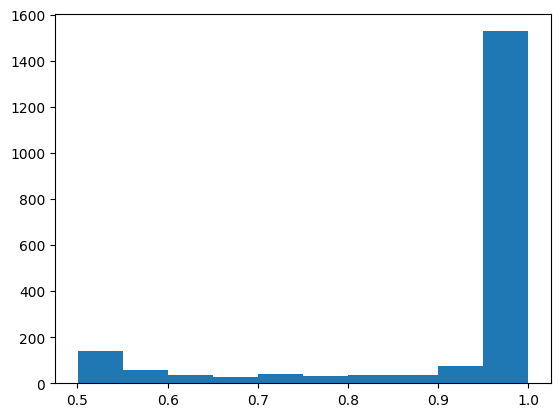

In [50]:
y_proba_ancestr_nodes = pipe.predict_proba(ancestral_nodes_tensor.cpu())
max_proba = [max(x) for x in y_proba_ancestr_nodes]
plt.hist(max_proba);

merged_df = pd.merge(diderm_annot, leaves_acc_names, on="accession", how="left")
merged_df = merged_df.rename(columns={"high_throughput_dermy": "didermy"})
merged_df

In [52]:
tree_node_names_list = tree_nodes_data.index.tolist()
print(len(tree_node_names_list))

correct = 0
total = 0

annot_vs_pred_label = []
oxytolerance = []
for idx, node in enumerate(tree_node_names_list):
    if node in list(merged_df['ShortCode']):
        oxytol = merged_df.loc[merged_df["ShortCode"] == node, "didermy"]
        oxytolerance.append(oxytol.iloc[0])
        annot_vs_pred_label.append("annot")
        if (oxytol.iloc[0] == "Monoderm" and y_pred_ancestr_nodes[idx] == 1) or (oxytol.iloc[0] == "Diderm" and y_pred_ancestr_nodes[idx] == 0):
            correct += 1
        total +=1    
        
    else:
        annot_vs_pred_label.append("predict")
        oxytolerance.append("Monoderm" if y_pred_ancestr_nodes[idx] == 1 else "Diderm")  #map({'Diderm': 0, 'Monoderm': 1})
#{"Monoderm": 1, "Diderm": 0}
df_pred = pd.DataFrame({
    'NodeName': tree_node_names_list,
    'didermy': oxytolerance,
    'annot_or_predict':annot_vs_pred_label,
    'max_proba': max_proba
})

print(f"Correct predict = {correct} of {total}; which is {correct/total}")


print(df_pred.loc[df_pred["NodeName"] == '2012', "didermy"].iloc[0])
print(df_pred.loc[df_pred["NodeName"] == '2012', "max_proba"].iloc[0])
df_pred

2013
Correct predict = 912 of 912; which is 1.0
Diderm
0.50412714


,NodeName,didermy,annot_or_predict,max_proba
0,1007,Diderm,predict,0.999260
1,1008,Diderm,predict,0.713730
2,1009,Diderm,predict,0.993666
3,1010,Diderm,predict,0.982967
4,1011,Diderm,predict,0.999992
...,...,...,...,...
2008,Zixi1,Diderm,annot,0.999924
2009,Zixi2,Diderm,annot,0.999965
2010,Zixi3,Diderm,annot,0.999768
2011,Zixi4,Diderm,annot,0.999958


In [53]:
def process_res(res):
    if not res.empty:
        res_predict_comm = res.iloc[0]
    else:
        res_predict_comm = ''
    return res_predict_comm  

In [54]:
from Bio import Phylo

tree = Phylo.read("../ancestral_data/C65.tree", "newick")

cog_names = ['COG0763', 'COG5009', 'COG0751', 'COG0751', 'COG0795']
for clade in tree.find_clades(order="level"):
    node_name = clade.name if clade.name is not None else str(clade.confidence)

    oxytol_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "didermy"])
    predict_annot_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "annot_or_predict"])
    max_proba_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "max_proba"])
    max_proba_comm = str(round(float(max_proba_comm), 2)) if max_proba_comm != '' else ''
   # cog_count = int(pivot_df.loc[node_name, cog_name]) if cog_name in pivot_df.columns else 0

    if oxytol_comm == "Monoderm":
        color = "#9467bd"  # tab:purple
    else:
        color = "#2ca02c"  # tab:green

    comment_str = f'&!color={color}, didermy={oxytol_comm}, predict_annot={predict_annot_comm},max_proba={max_proba_comm}'#,,{cog_name}={str(cog_count)}'     

    for cog_name in cog_names:
        cog_count = int(pivot_df.loc[node_name, cog_name]) if cog_name in pivot_df.columns else -1  
        if cog_count > 1:
            cog_count = 1
        comment_str += f',{cog_name}={str(cog_count)}'
    
    clade.comment = comment_str#f'&!color={color}, didermy={oxytol_comm}, predict_annot={predict_annot_comm},max_proba={max_proba_comm},{cog_name}={str(cog_count)}'

filename =   f"../ancestral_data/diderm_C65_annotated_on_noisy_train_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x}.tree"  
Phylo.write(tree, filename, "nexus")
filename

'../ancestral_data/diderm_C65_annotated_on_noisy_train_fp_0.1_fn_0.5_noise_type_exp_x_100.tree'